In [3]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from scipy.linalg import qr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors


In [4]:
# fetch dataset 
communities_and_crime = fetch_ucirepo(id=183) 
  
# data (as pandas dataframes) 
X = communities_and_crime.data.features
y = communities_and_crime.data.targets
df = pd.concat([X, y], axis=1)
# change ? (missing value indicator) to NAs and drop columns with missing values
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(axis=1)
# dropping these categorical columns rather than one-hot encoding them because 
# if we include only some of the one-hot encoded ones that's a bit weird
df_clean.drop(columns=["state", "fold"], inplace=True)
df_clean

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/147206845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=["state", "fold"], inplace=True)


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.00,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.00,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.91,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.22,0.19


In [93]:
y_clean = df_clean[['ViolentCrimesPerPop']].values
X_clean = df_clean.drop(columns=['ViolentCrimesPerPop']).values
n, m = np.shape(X_clean)
# randomly order the data and the columns
idx = np.random.permutation(n)
X_clean = X_clean[idx]
y_clean = y_clean[idx]
# for random order:
ordering = 0
col_idx = np.random.permutation(m)
X_clean = X_clean[:, col_idx]
# for ordering by weight in theta_full
# ordering = 1
# theta_full = np.linalg.lstsq(X_clean, y_clean, rcond=None)[0]
# col_idx = np.argsort(theta_full.flatten())
# X_clean = X_clean[:, col_idx]

# for ordering by QR decomp of X_clean (M)
# ordering = 2
# _, R, P = qr(X_clean, pivoting=True)
# X_clean = X_clean[:, P]
n_train = 100
X_train = X_clean[:n_train, :]
y_train = y_clean[:n_train]
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = X_clean[n_train:, :]
y_val = y_clean[n_train:]
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


In [97]:
n_epochs = 300

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


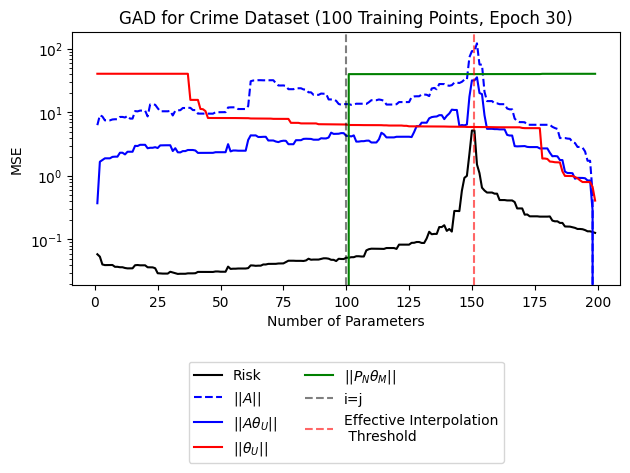

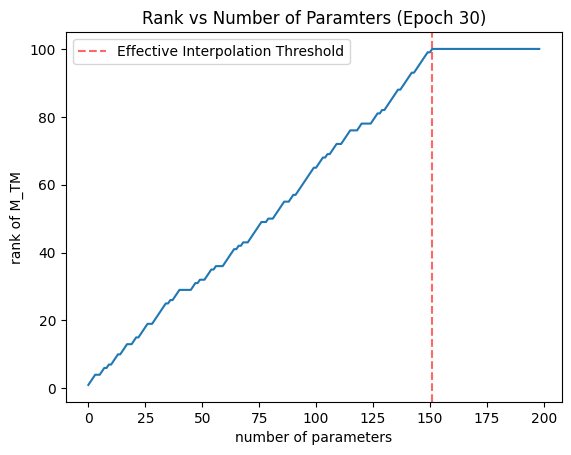

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


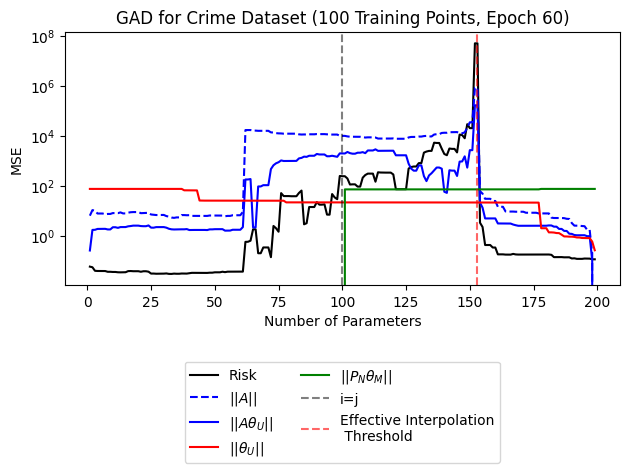

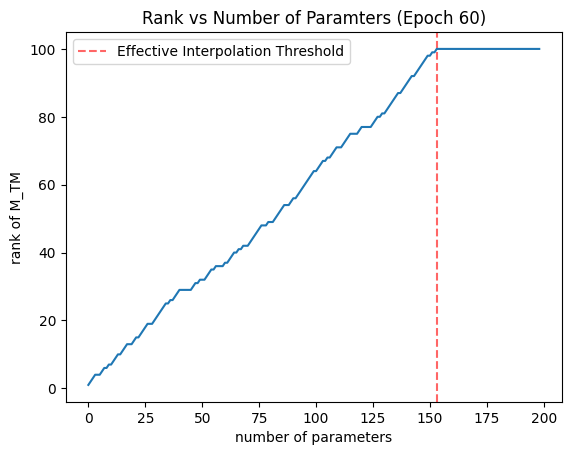

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


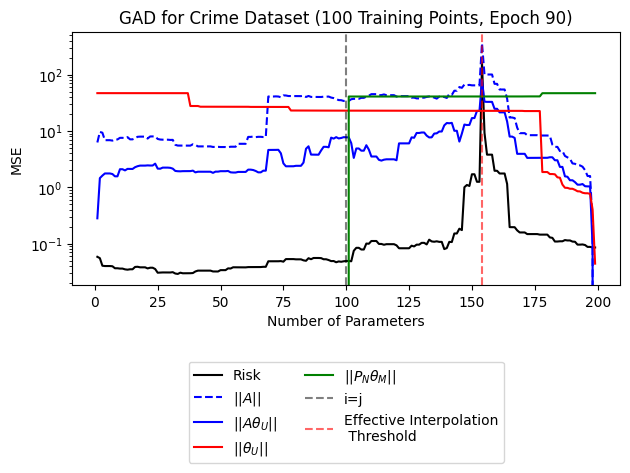

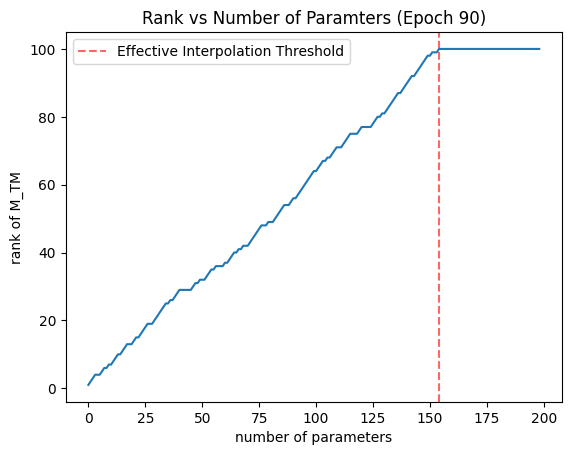

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


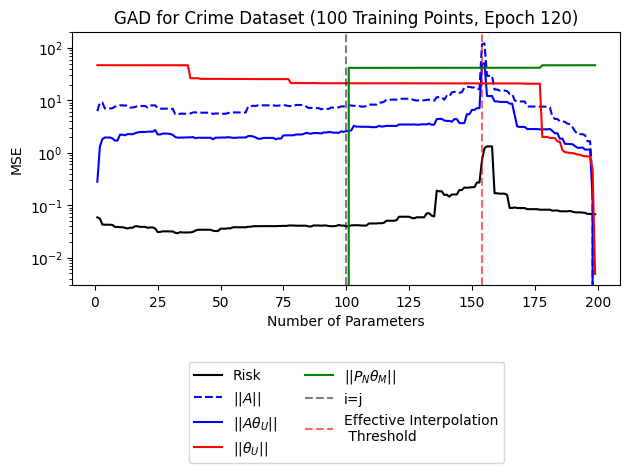

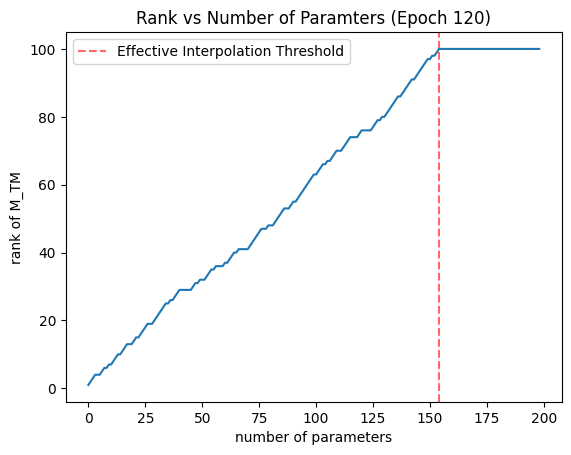

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


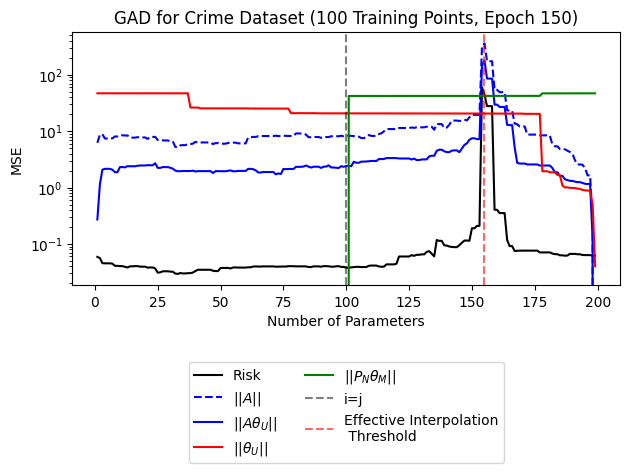

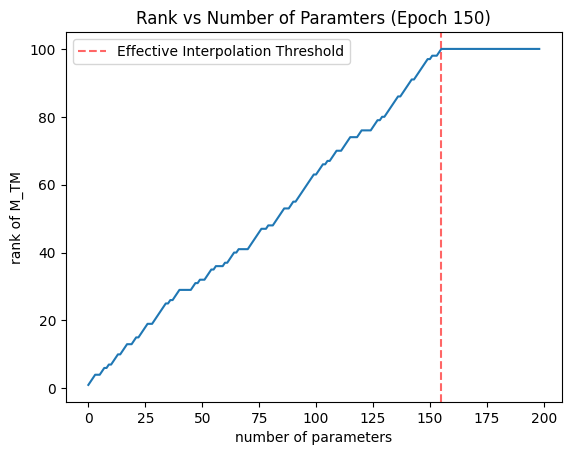

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


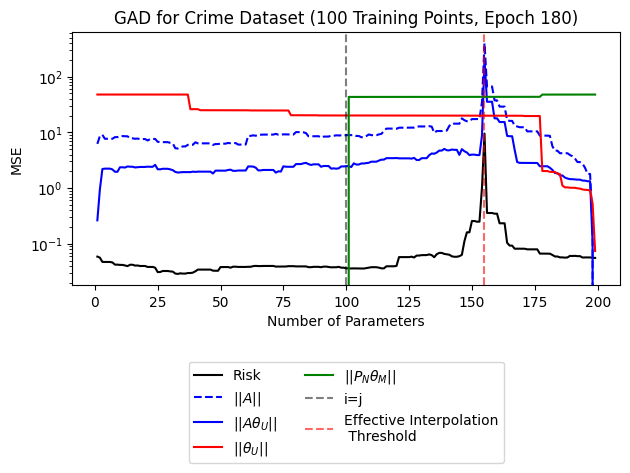

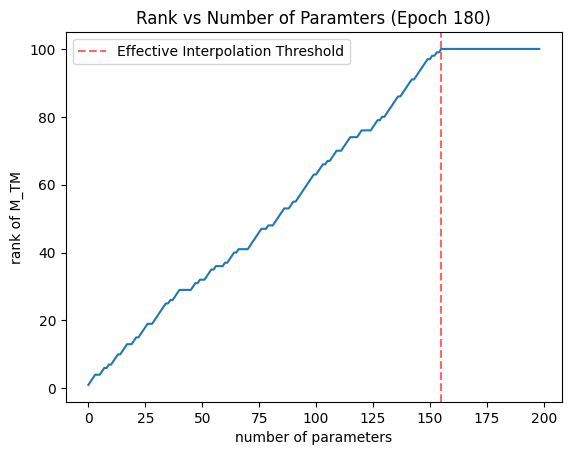

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


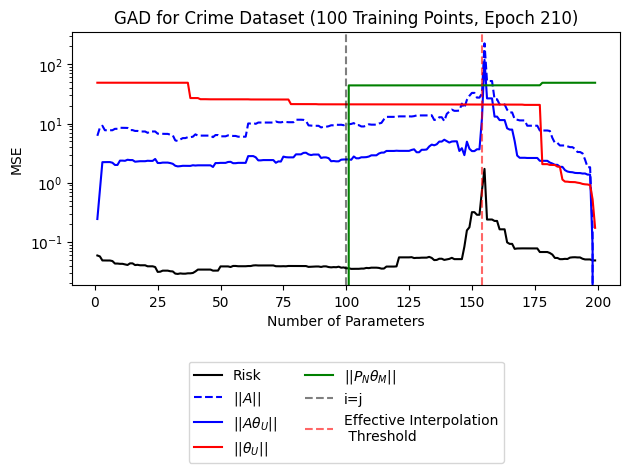

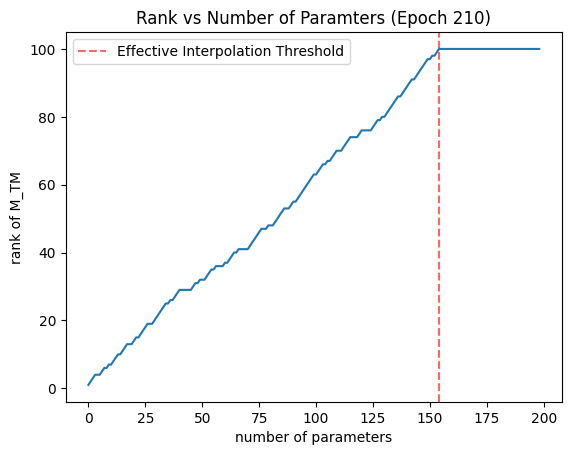

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


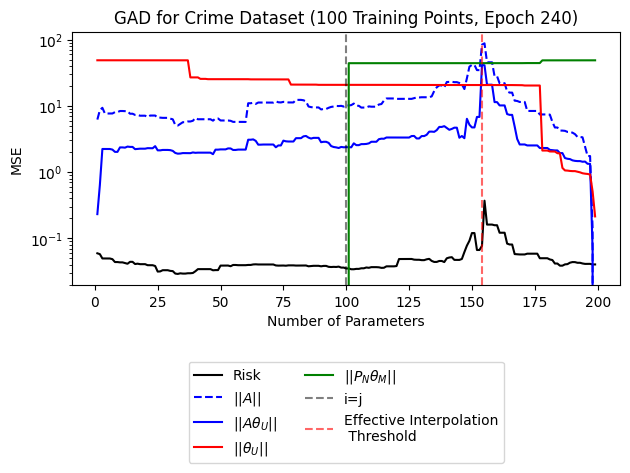

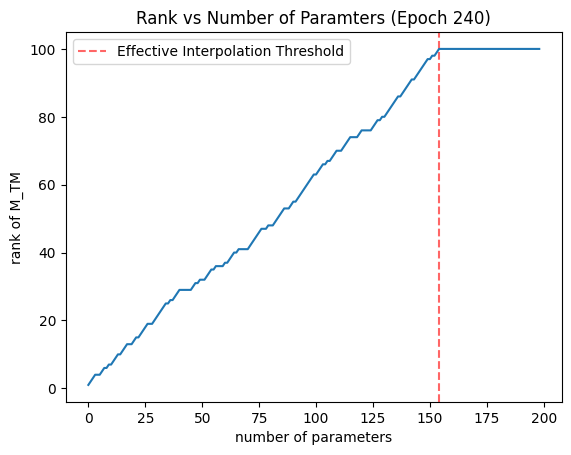

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


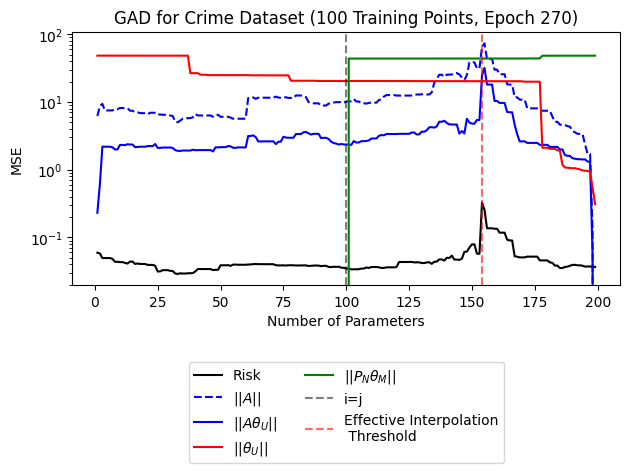

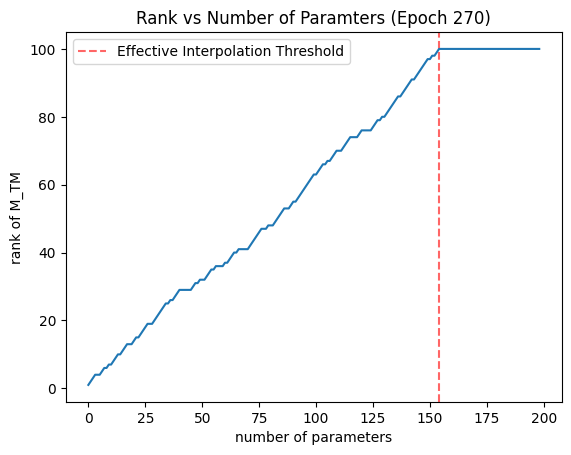

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3790321711.py:89: RuntimeWarning: invalid value encountered in scalar divide
  independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)


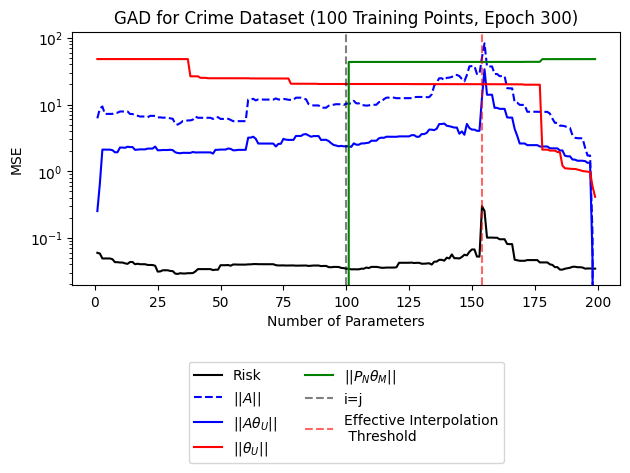

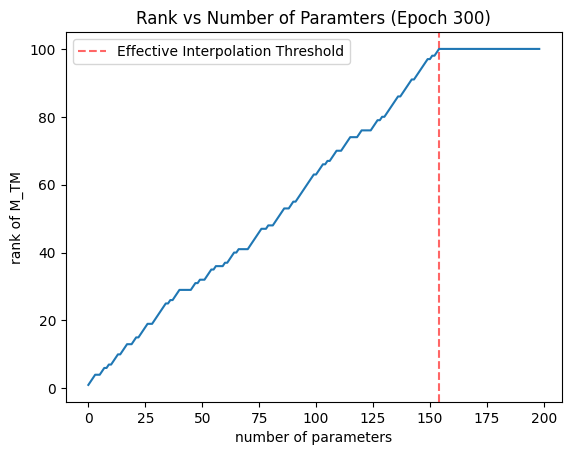

In [98]:
class GADNet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden = nn.Linear(in_dim, hidden_dim)
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def features(self, x):
        # this is your Conjugate Kernel feature map at the current weights
        return self.act(self.hidden(x))

    def forward(self, x):
        return self.out(self.features(x))
m = 200

model = GADNet(in_dim=99, hidden_dim=m)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
losses = []
for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()       # clear old gradients
    preds = model(X_train)      # forward pass
    loss = loss_fn(preds, y_train)
    losses.append(float(loss))
    loss.backward()             # backprop
    optimizer.step()            # update weights
    if epoch % 30 == 0: # checkpoint every 5 epochs
        with torch.no_grad():
            M_train = model.features(X_train).numpy()
            M_val   = model.features(X_val).numpy()
            M = np.vstack((M_train, M_val))
            
        error = np.zeros(m)
        test_error = np.zeros(m)
        norm_A = np.zeros(m)
        norm_PN_theta = np.zeros(m)
        norm_theta_U = np.zeros(m)
        norm_A_theta_u = np.zeros(m - 1)
        norm_pinv_MTM = np.zeros(m - 1)
        first_spectral_val = np.zeros(m - 1)
        second_spectral_val = np.zeros(m - 1)
        independence = np.zeros(m - 1)
        ranks = np.zeros(m - 1)

        risk = np.zeros(m - 1)
        N = n_train
        # calculating theta_full with all the data so it's closer to the true value
        theta_full = np.linalg.lstsq(M, y_clean, rcond=None)[0]
        
        for i in range(1, m):
            # breaking up the matrix and vectors
            M_TM = M[:N, :i]
            M_TU = M[:N, i:]
            M_PM = M[N:, :i]
            M_PU = M[N:, i:]
            theta_M = theta_full[:i]
            theta_U = theta_full[i:]

            M_TM_pinv = np.linalg.pinv(M_TM)  
            theta_hat = M_TM_pinv @ y_clean[:N]
            
            y_hat = M_TM @ theta_hat
            y_test_hat = M[N:, :i] @ theta_hat
            error[i] = np.linalg.norm(y_hat - y_clean[:N]) / N
            test_error[i] = np.linalg.norm(y_test_hat - y_clean[N:]) / (len(y_test_hat))
            risk[i - 1] = np.linalg.norm(np.vstack((y_hat, y_test_hat)) - y_clean)**2 / len(y_clean)
            
            A = M_TM_pinv @ M_TU
            norm_A[i] = np.linalg.norm(A, ord=2)
            
            B = M_TM_pinv @ M_TM
            PN = np.eye(i) - B
            if i > N:
                norm_PN_theta[i] = np.linalg.norm(PN@theta_M)
            
            norm_theta_U[i] = np.linalg.norm(theta_U)
            norm_A_theta_u[i - 1] = np.linalg.norm(A @ theta_U)

            norm_pinv_MTM[i - 1] = np.linalg.norm(M_TM_pinv, ord=2)
            U, s, Vh = np.linalg.svd(M_TM_pinv)
            first_spectral_val[i - 1] = s[0]
            if i > 1:
                second_spectral_val[i - 1] = s[1]
            if i < m:
                new_col = M[:N, i:i+1]
                projection = M_TM @ np.linalg.pinv(M_TM) @ new_col
                residual = new_col - projection
                
                independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)
            ranks[i - 1] = np.linalg.matrix_rank(M_TM)
        plt.figure(figsize=(6.4,5.8))
        plt.semilogy(np.arange(1, m), risk, label='Risk', color="black")
        # plt.semilogy(np.arange(1, m), error[1:], label="In-Sample Error")
        plt.semilogy(np.arange(1, m), norm_A[1:], label=r"$|| A ||$", color="blue", linestyle='--')
        plt.semilogy(np.arange(1, m), norm_A_theta_u, label=r"$|| A \theta_U||$", color="blue")
        plt.semilogy(np.arange(1, m), norm_theta_U[1:], label=r"$||\theta_U||$", color="red")
        plt.semilogy(np.arange(1, m), norm_PN_theta[1:], label=r"||$P_N \theta_M$||", color="green")

        plt.title(f"GAD for Crime Dataset ({N} Training Points, Epoch {epoch})")
        plt.xlabel("Number of Parameters")
        plt.ylabel("MSE")
        plt.axvline([N], color='black', linestyle='--', alpha=0.5, label="i=j")
        min_full_rank = np.argmin(np.abs(ranks - n_train))
        plt.axvline([min_full_rank], color='red', linestyle='--', alpha=0.6, label=f'Effective Interpolation\n Threshold')

        plt.legend(loc='center', bbox_to_anchor=(0.5,-0.5),ncol=2)
        plt.tight_layout()
        if ordering == 0:
            plt.savefig(f'./plots/gad183_{N}points.jpg')
        if ordering == 1:
            plt.savefig(f'./plots/ordered_gad183_{N}points.jpg')
        if ordering == 2:
            plt.savefig(f'./plots/qr_ordered_gad183_{N}points.jpg')
        plt.show()
        plt.figure(figsize=(6.4,4.8))
        plt.title(f"Rank vs Number of Paramters (Epoch {epoch})")
        plt.xlabel("number of parameters")
        plt.ylabel("rank of M_TM")
        plt.axvline([min_full_rank], color='red', linestyle='--', alpha=0.6, label='Effective Interpolation Threshold')
        plt.plot(ranks)
        plt.legend()
        plt.show()

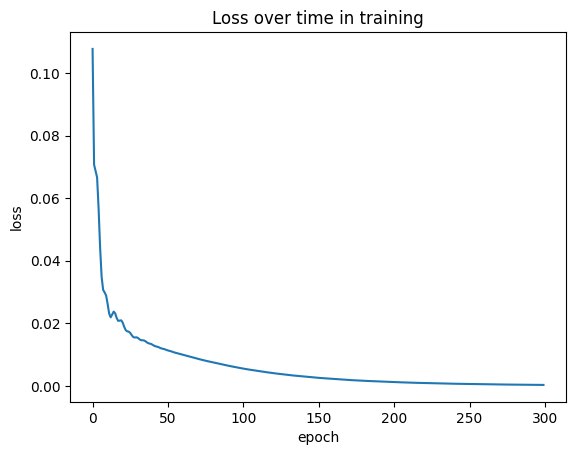

In [99]:
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(losses)
plt.title("Loss over time in training")
plt.show()